In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("all_data.csv")

In [3]:
data.head()

,Time,COURANT ValueY,DEBIT EAU ValueY,SOLIDE ValueY,PUISSANCE ValueY,refus_tamis
0,2022-01-28 00:00:00,67.253113,10.185185,121.003326,576.604736,20.84982
1,2022-01-28 00:01:00,67.253113,10.185185,121.003326,576.604736,20.84982
2,2022-01-28 00:02:00,67.253113,10.185185,121.003326,576.604736,20.84982
3,2022-01-28 00:03:00,67.253113,10.185185,121.003326,576.604736,20.84982
4,2022-01-28 00:04:00,67.253113,10.185185,121.003326,576.604736,20.84982


In [4]:
df = data.copy()

In [5]:
df.shape

(104561, 6)

In [8]:
df.dtypes

Time                 object
COURANT ValueY      float64
DEBIT EAU ValueY    float64
SOLIDE ValueY       float64
PUISSANCE ValueY    float64
refus_tamis         float64
dtype: object

In [9]:
df['Time'] = pd.to_datetime(df['Time'], format="%Y/%m/%d %H:%M:%S")

In [10]:
df.dtypes.value_counts()

float64           5
datetime64[ns]    1
dtype: int64

<AxesSubplot:>

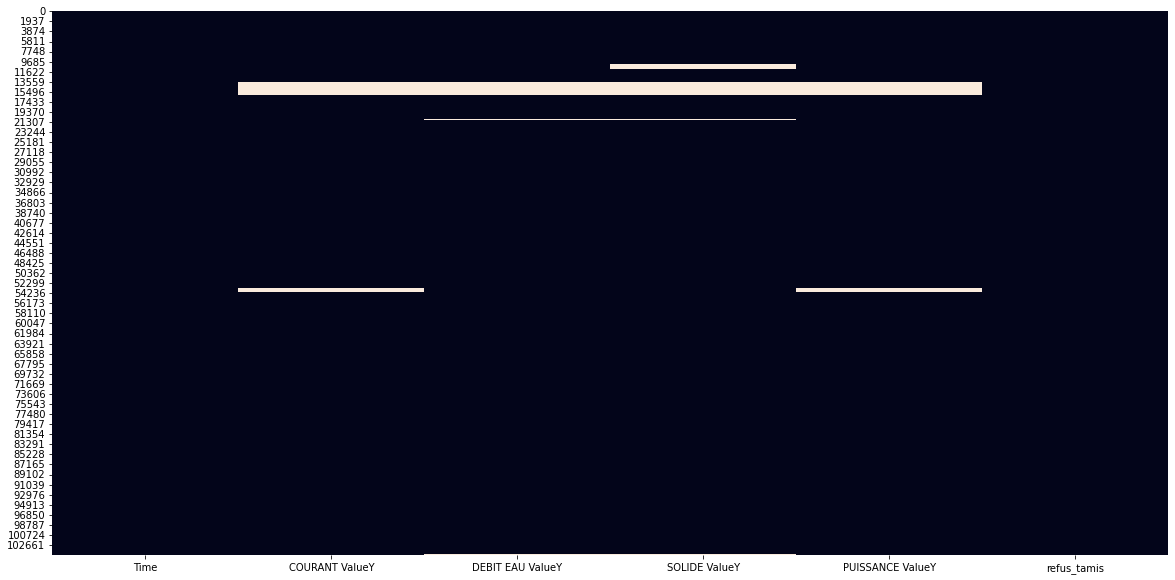

In [11]:
plt.figure(figsize=(20,10))
sns.heatmap(df.isna(), cbar=False)

In [26]:
(df.isna().sum()).sort_values(ascending=True)

Time                   0
refus_tamis            0
DEBIT EAU ValueY    2940
PUISSANCE ValueY    3490
COURANT ValueY      3612
SOLIDE ValueY       3839
dtype: int64

In [12]:
(df.isna().sum()/df.shape[0]).sort_values(ascending=True)

Time                0.000000
refus_tamis         0.000000
DEBIT EAU ValueY    0.028118
PUISSANCE ValueY    0.033378
COURANT ValueY      0.034544
SOLIDE ValueY       0.036715
dtype: float64

In [32]:
df_puissance_nan = df[df["PUISSANCE ValueY"].isna()]
df_puissance_nan

,Time,COURANT ValueY,DEBIT EAU ValueY,SOLIDE ValueY,PUISSANCE ValueY,refus_tamis
10560,2022-02-04 08:00:00,NaN,NaN,NaN,NaN,25.668804
10561,2022-02-04 08:01:00,NaN,NaN,NaN,NaN,25.668804
10562,2022-02-04 08:02:00,NaN,NaN,NaN,NaN,25.668804
10563,2022-02-04 08:03:00,NaN,NaN,NaN,NaN,25.668804
10564,2022-02-04 08:04:00,NaN,NaN,NaN,NaN,25.668804
...,...,...,...,...,...,...
79916,2022-10-03 14:17:00,NaN,NaN,NaN,NaN,18.734397
81983,2022-10-05 00:44:00,NaN,NaN,NaN,NaN,19.810611
81984,2022-10-05 00:45:00,NaN,NaN,NaN,NaN,19.810611
92993,2022-10-12 16:14:00,NaN,NaN,NaN,NaN,19.304626


In [34]:
(df_puissance_nan.isna().sum()/df_puissance_nan.shape[0]).sort_values(ascending=True)

Time                0.000000
refus_tamis         0.000000
DEBIT EAU ValueY    0.760745
SOLIDE ValueY       0.763897
COURANT ValueY      0.995989
PUISSANCE ValueY    1.000000
dtype: float64

In [35]:
df = df.dropna(subset=['PUISSANCE ValueY']).reset_index(drop=True)

In [36]:
(df.isna().sum()/df.shape[0]).sort_values(ascending=True)

Time                0.000000
PUISSANCE ValueY    0.000000
refus_tamis         0.000000
COURANT ValueY      0.001346
DEBIT EAU ValueY    0.002820
SOLIDE ValueY       0.011606
dtype: float64

c:\Users\Amine DD\AppData\Local\Programs\Python\Python38\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
c:\Users\Amine DD\AppData\Local\Programs\Python\Python38\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
c:\Users\Amine DD\AppData\Local\Programs\Python\Python38\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to us

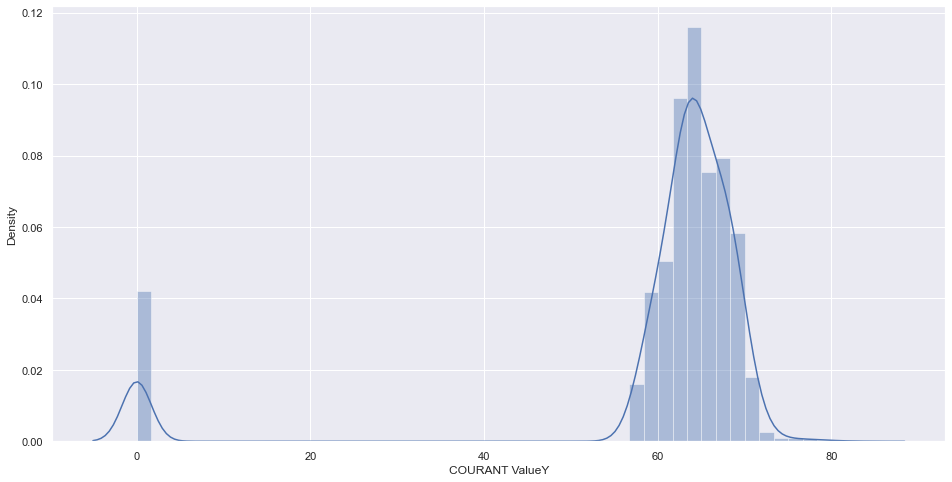

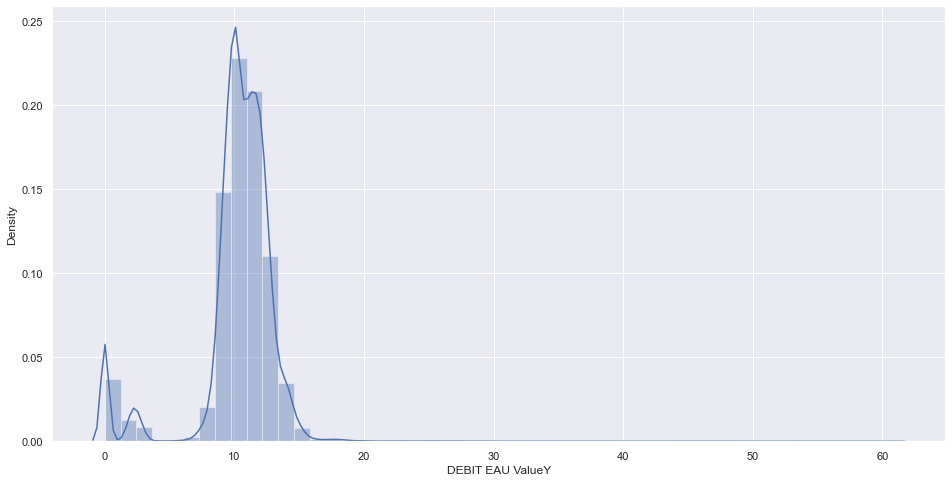

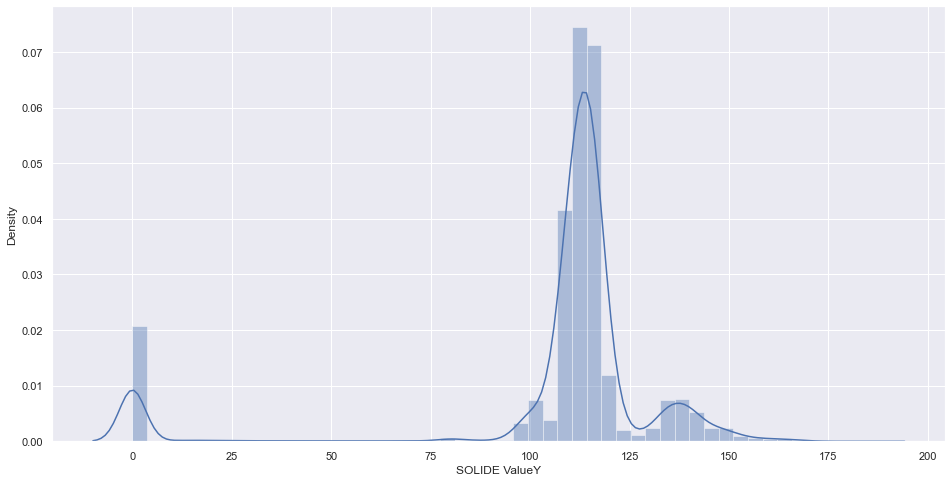

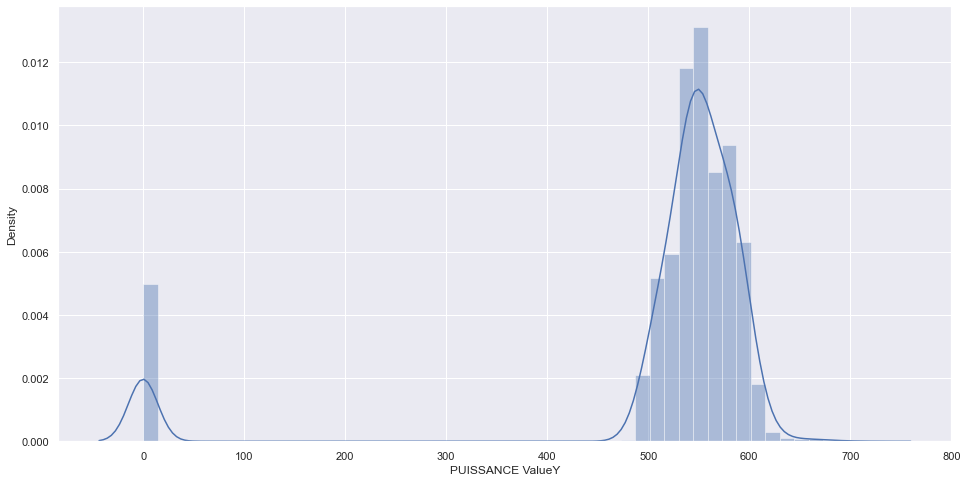

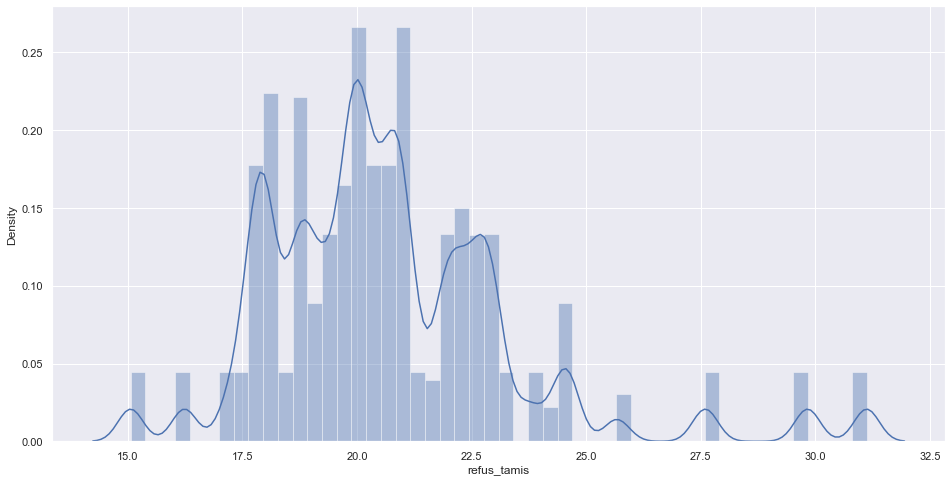

In [37]:
for col in df.select_dtypes('float'):
    plt.figure()
    sns.distplot(df[col])

Relation Variable Target

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

<AxesSubplot:xlabel='refus_tamis', ylabel='PUISSANCE ValueY'>

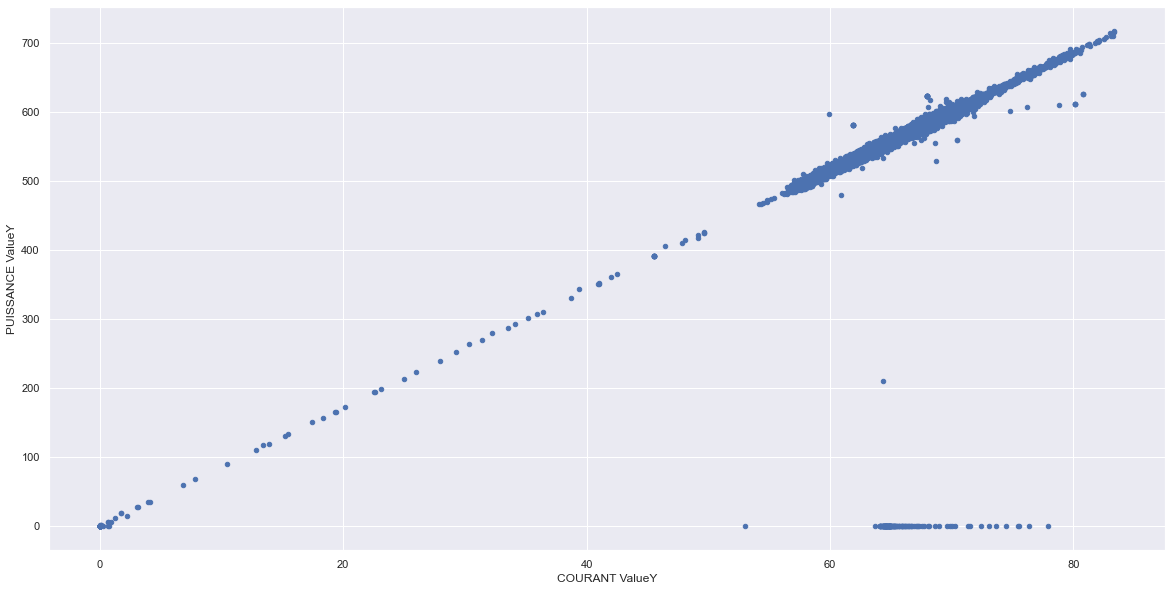

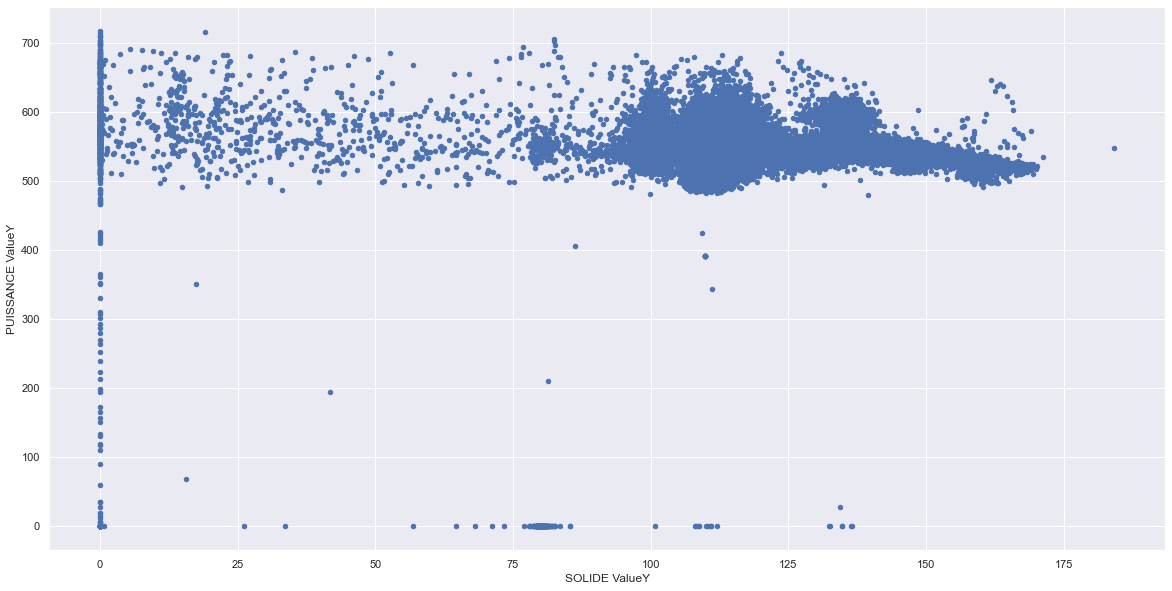

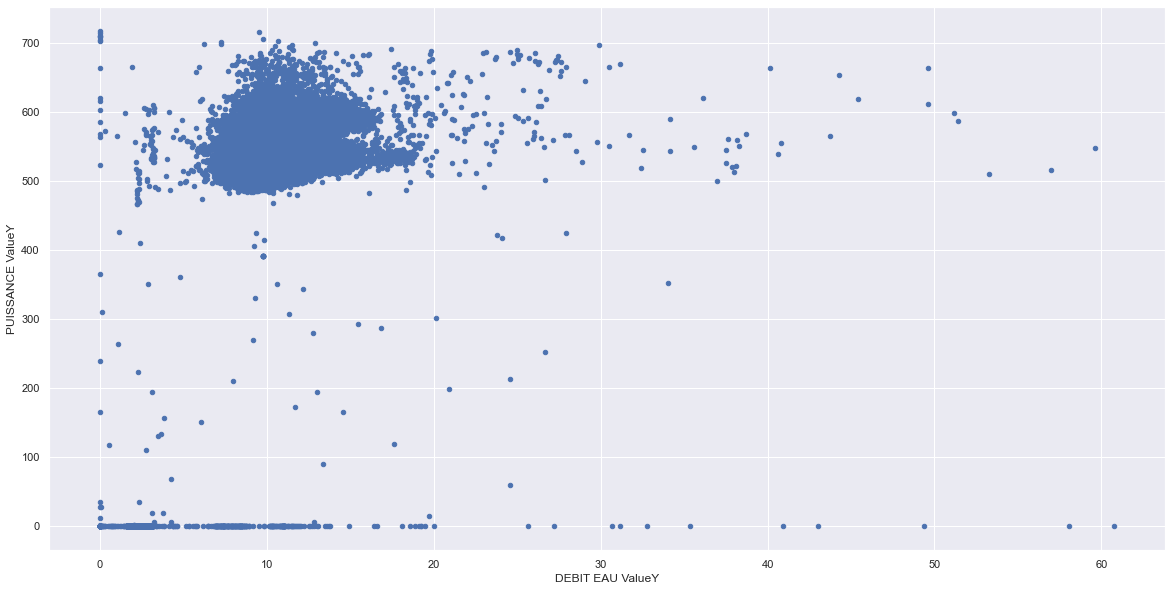

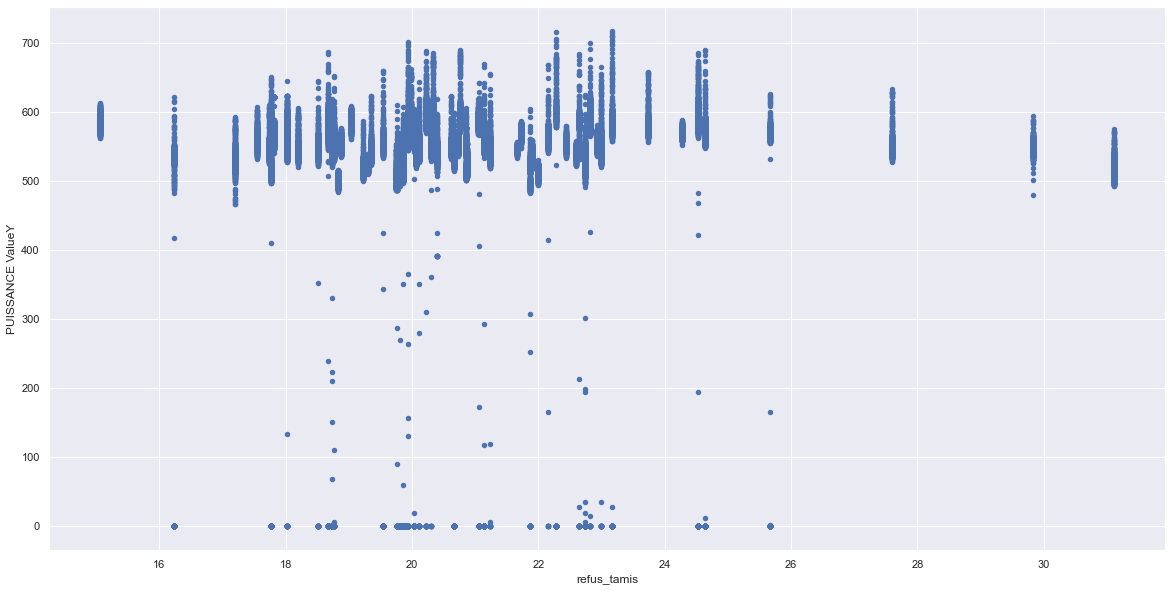

In [38]:
df.plot.scatter(x='COURANT ValueY', y='PUISSANCE ValueY', marker='o', figsize=(20,10))
df.plot.scatter(x='SOLIDE ValueY', y='PUISSANCE ValueY', marker='o', figsize=(20,10))
df.plot.scatter(x='DEBIT EAU ValueY', y='PUISSANCE ValueY', marker='o', figsize=(20,10))
df.plot.scatter(x='refus_tamis', y='PUISSANCE ValueY', marker='o', figsize=(20,10))

Relation variable/variable

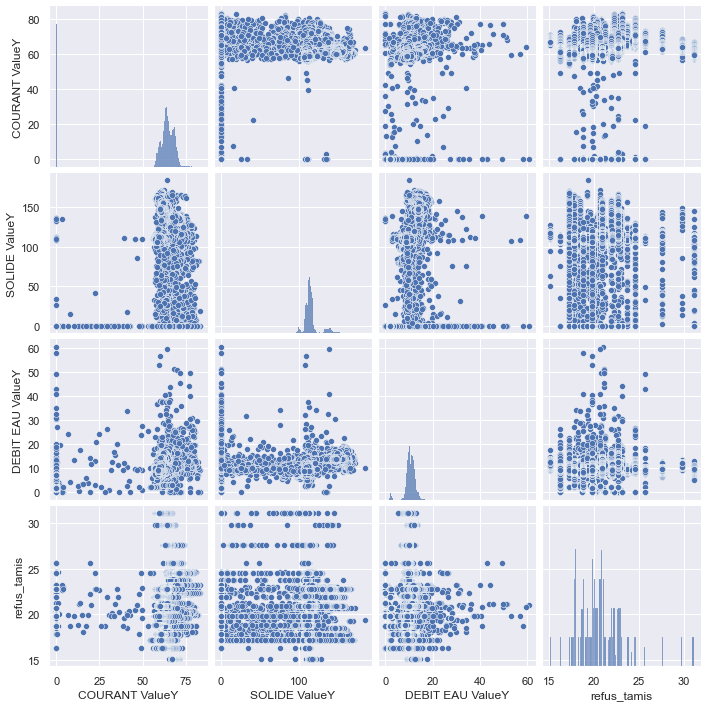

In [39]:
cl = ["COURANT ValueY","SOLIDE ValueY","DEBIT EAU ValueY","refus_tamis"]
sns.pairplot(df[cl])

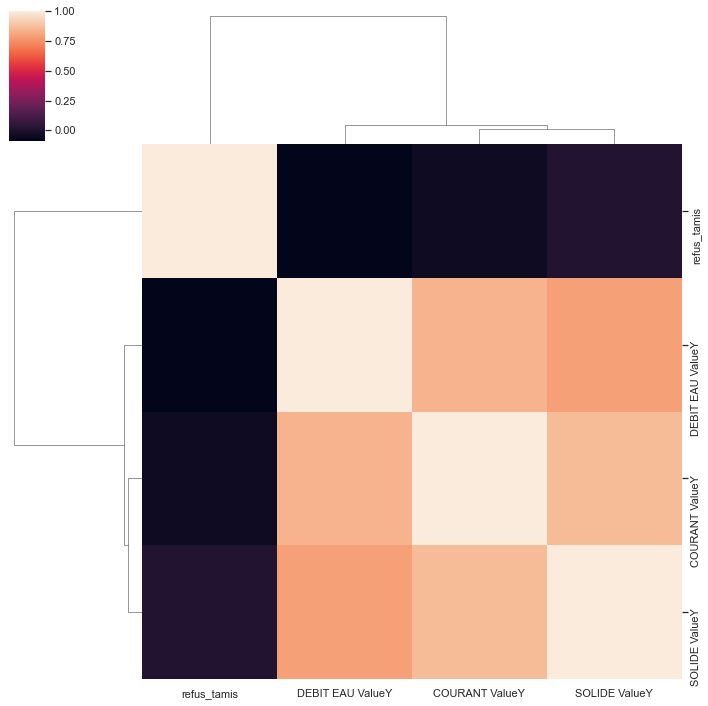

In [40]:
sns.clustermap(df[cl].corr())

Correlation with target

<AxesSubplot:>

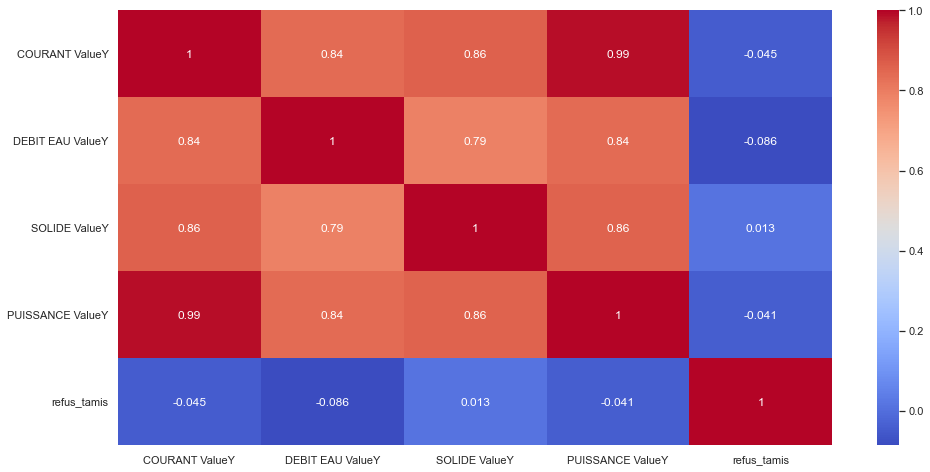

In [41]:
sns.set(rc = {'figure.figsize':(16,8)})
sns.heatmap(df.corr(), annot = True, fmt='.2g',cmap= 'coolwarm')

Text(0.5, 1.0, 'Boxplot of PUISSANCE ValueY')

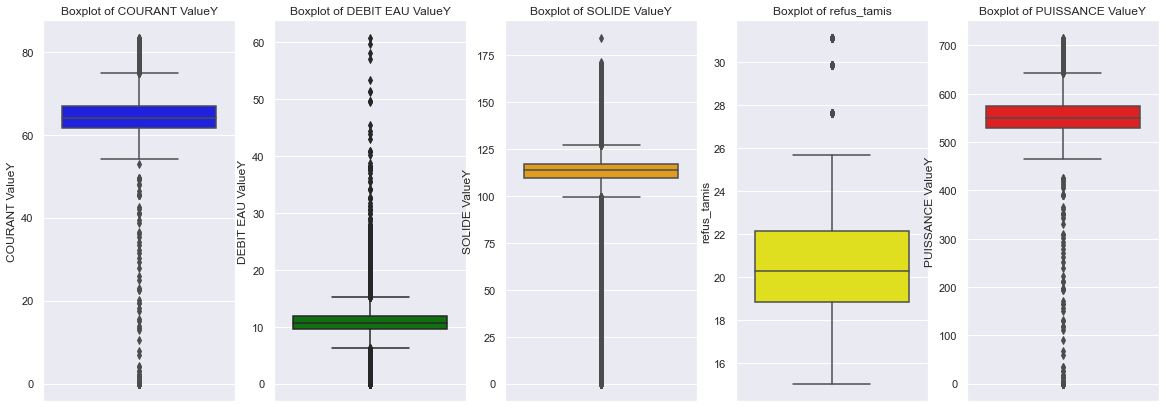

In [45]:
# setup figure
fig, ax = plt.subplots(1,5, figsize=(20,7))

# plot1
g1 = sns.boxplot(y=df["COURANT ValueY"], color='blue', ax=ax[0])
g1.set_title('Boxplot of COURANT ValueY')

# plot2
g2 = sns.boxplot(y=df["DEBIT EAU ValueY"], color='green', ax=ax[1])
g2.set_title('Boxplot of DEBIT EAU ValueY')

# plot3
g3 = sns.boxplot(y=df["SOLIDE ValueY"], color='orange', ax=ax[2])
g3.set_title('Boxplot of SOLIDE ValueY')

# plot4
g4 = sns.boxplot(y=df["refus_tamis"], color='yellow', ax=ax[3])
g4.set_title('Boxplot of refus_tamis')

# plot5
g5 = sns.boxplot(y=df["PUISSANCE ValueY"], color='red', ax=ax[4])
g5.set_title('Boxplot of PUISSANCE ValueY')

On doit ici supprimer les outliers , ms c'est une tache à faire aprés.

In [42]:
df.to_csv("data.csv", index=False)